# 03b — E1.1 Face-Crop Baseline CNN Training

**Experiment:** E1.1 — Baseline CNN trained on RetinaFace-cropped FaceForensics++ frames  
**Purpose:** Isolate the effect of face-focused preprocessing on the same shallow CNN used in E1.

This notebook trains only. It never reads the test split. Use `04b_E11_FFPP_Evaluation.ipynb` after training.


## Controlled experimental design

- **Control:** E1 full-frame baseline CNN
- **Independent variable:** full RGB frame replaced by a RetinaFace crop
- **Held constant:** CNN architecture, 128×128 model input, normalisation, Adam optimiser, learning rate 0.001, batch size 32, five epochs, seed 42, and source-video manifest
- **Face preprocessing:** crops were saved at 224×224 using the fixed 15% width/height margin, then resized to 128×128 for this CNN
- **Checkpoint strategy:** final epoch, matching E1


## 1. Safety control

Training and checkpoint overwrite are disabled by default. Set `RUN_TRAINING=True` only when intentionally running E1.1. If a checkpoint already exists, explicitly set `ALLOW_CHECKPOINT_OVERWRITE=True`.


In [ ]:
RUN_TRAINING = True
ALLOW_CHECKPOINT_OVERWRITE = False

SEED = 42
NUM_EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_WORKERS = 0

CHECKPOINT_NAME = "baseline_cnn_face.pth"
RESULTS_NAME = "baseline_cnn_face_results.json"

print("E1.1 training enabled:", RUN_TRAINING)
print("Allow checkpoint overwrite:", ALLOW_CHECKPOINT_OVERWRITE)
print("Seed:", SEED)

E1.1 training enabled: True
Allow checkpoint overwrite: False
Seed: 42


## 2. Imports, paths, reproducibility and safety checks


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import json
import os
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

BASE_PATH = "/content/drive/MyDrive/deepfake_project"
TRAIN_DIR = os.path.join(BASE_PATH, "face_dataset", "train")
VAL_DIR = os.path.join(BASE_PATH, "face_dataset", "val")
MODEL_PATH = os.path.join(BASE_PATH, "saved_models", CHECKPOINT_NAME)
RESULTS_PATH = os.path.join(BASE_PATH, "results", RESULTS_NAME)
PLOT_PATH = os.path.join(BASE_PATH, "plots", "baseline_cnn_face_training.png")
SPLIT_MANIFEST_PATH = os.path.join(BASE_PATH, "ffpp_video_split_manifest.json")

for required_path, description in [
    (TRAIN_DIR, "Training directory"),
    (VAL_DIR, "Validation directory"),
    (SPLIT_MANIFEST_PATH, "Video-level split manifest"),
]:
    if not os.path.exists(required_path):
        raise FileNotFoundError(f"{description} not found: {required_path}")

if RUN_TRAINING and os.path.exists(MODEL_PATH) and not ALLOW_CHECKPOINT_OVERWRITE:
    raise FileExistsError(
        f"E1.1 checkpoint already exists: {MODEL_PATH}\n"
        "Set ALLOW_CHECKPOINT_OVERWRITE=True only when replacement is intentional."
    )

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA is unavailable; complete training will run more slowly on CPU.")
print("Training data:", TRAIN_DIR)
print("Validation data:", VAL_DIR)
print("Checkpoint:", MODEL_PATH)

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Training data: /content/drive/MyDrive/deepfake_project/face_dataset/train
Validation data: /content/drive/MyDrive/deepfake_project/face_dataset/val
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/baseline_cnn_face.pth


## 3. Validate the clean face-crop datasets

The expected counts reflect RetinaFace detection failures recorded during preprocessing. Missing crops are not silently replaced. Source-video identities must remain disjoint across training and validation.


In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5],
    ),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform)

EXPECTED_CLASS_MAPPING = {"fake": 0, "real": 1}
if train_dataset.class_to_idx != EXPECTED_CLASS_MAPPING:
    raise ValueError(
        f"Unexpected training class mapping: {train_dataset.class_to_idx}"
    )
if val_dataset.class_to_idx != EXPECTED_CLASS_MAPPING:
    raise ValueError(
        f"Unexpected validation class mapping: {val_dataset.class_to_idx}"
    )


def named_class_counts(dataset):
    numeric_counts = Counter(dataset.targets)
    return {
        class_name: numeric_counts[class_index]
        for class_name, class_index in dataset.class_to_idx.items()
    }


train_class_counts = named_class_counts(train_dataset)
val_class_counts = named_class_counts(val_dataset)

if train_class_counts != {"fake": 1398, "real": 1342}:
    raise RuntimeError(f"Unexpected training counts: {train_class_counts}")
if val_class_counts != {"fake": 300, "real": 290}:
    raise RuntimeError(f"Unexpected validation counts: {val_class_counts}")


def recover_video_ids(dataset):
    identifiers = set()
    for image_path, _ in dataset.samples:
        stem = os.path.splitext(os.path.basename(image_path))[0]
        if "_frame_" not in stem:
            raise ValueError(f"Cannot recover source-video id from: {image_path}")
        identifiers.add(stem.rsplit("_frame_", 1)[0])
    return identifiers


train_video_ids = recover_video_ids(train_dataset)
val_video_ids = recover_video_ids(val_dataset)

with open(SPLIT_MANIFEST_PATH, "r", encoding="utf-8") as manifest_file:
    split_manifest = json.load(manifest_file)

expected_train_video_ids = {
    os.path.splitext(video_name)[0]
    for class_splits in split_manifest["classes"].values()
    for video_name in class_splits["train"]
}
expected_val_video_ids = {
    os.path.splitext(video_name)[0]
    for class_splits in split_manifest["classes"].values()
    for video_name in class_splits["val"]
}
if train_video_ids != expected_train_video_ids:
    raise RuntimeError("Face-crop training videos do not match the split manifest.")
if val_video_ids != expected_val_video_ids:
    raise RuntimeError("Face-crop validation videos do not match the split manifest.")
train_val_overlap = train_video_ids & val_video_ids
if train_val_overlap:
    raise RuntimeError(
        f"Train/validation source-video overlap detected: {sorted(train_val_overlap)[:5]}"
    )

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)
print("Training class counts:", train_class_counts)
print("Validation class counts:", val_class_counts)
print("Training source videos:", len(train_video_ids))
print("Validation source videos:", len(val_video_ids))
print("Train/validation overlapping videos:", len(train_val_overlap))
print("PASS: E1.1 face-crop data validation completed.")

Classes: ['fake', 'real']
Class mapping: {'fake': 0, 'real': 1}
Training class counts: {'fake': 1398, 'real': 1342}
Validation class counts: {'fake': 300, 'real': 290}
Training source videos: 280
Validation source videos: 60
Train/validation overlapping videos: 0
PASS: E1.1 face-crop data validation completed.


## 4. E1.1 model definition

This architecture is identical to E1. Only the image content has changed from full frames to face crops.


In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = BaselineCNN().to(DEVICE)
print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


## 5. Train and save E1.1

The final-epoch checkpoint is saved to preserve direct comparability with E1. The complete training history and best validation epoch are recorded separately in JSON.


Epoch [1/5], Loss: 0.6719, Validation Accuracy: 57.46%
Epoch [2/5], Loss: 0.6007, Validation Accuracy: 56.61%
Epoch [3/5], Loss: 0.5590, Validation Accuracy: 64.41%
Epoch [4/5], Loss: 0.5200, Validation Accuracy: 64.07%
Epoch [5/5], Loss: 0.4752, Validation Accuracy: 59.15%
Final-epoch model saved to: /content/drive/MyDrive/deepfake_project/saved_models/baseline_cnn_face.pth
Results saved to: /content/drive/MyDrive/deepfake_project/results/baseline_cnn_face_results.json
Best validation epoch: 3
Best validation accuracy: 64.41%


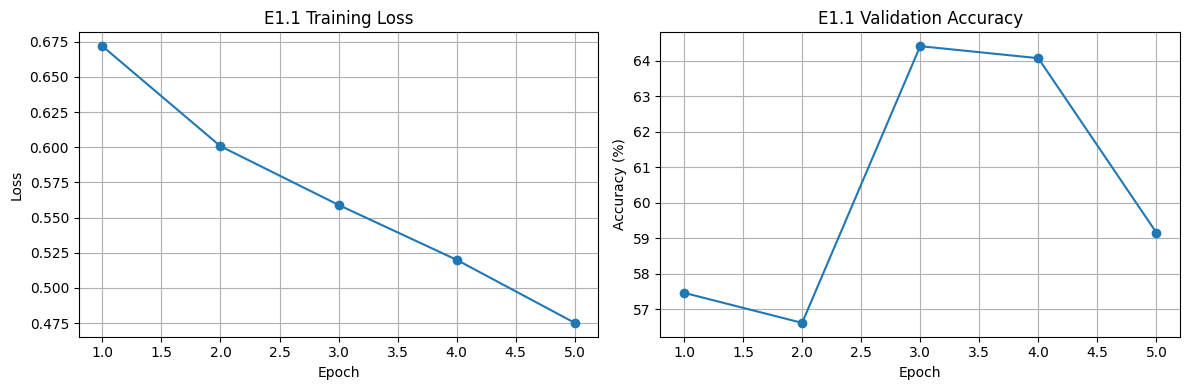

Training plot saved to: /content/drive/MyDrive/deepfake_project/plots/baseline_cnn_face_training.png


In [ ]:
if RUN_TRAINING:
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    train_losses = []
    val_accuracies = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        average_loss = running_loss / len(train_loader)
        train_losses.append(average_loss)

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                labels = labels.to(DEVICE, non_blocking=True)
                outputs = model(images)
                predictions = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()

        validation_accuracy = 100.0 * correct / total
        val_accuracies.append(validation_accuracy)

        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}], "
            f"Loss: {average_loss:.4f}, "
            f"Validation Accuracy: {validation_accuracy:.2f}%"
        )

    best_epoch_index = int(np.argmax(val_accuracies))
    best_epoch = best_epoch_index + 1
    best_val_accuracy = val_accuracies[best_epoch_index]

    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(PLOT_PATH), exist_ok=True)

    torch.save(model.state_dict(), MODEL_PATH)
    print("Final-epoch model saved to:", MODEL_PATH)

    results = {
        "experiment": "E1.1",
        "research_question": "Does RetinaFace face cropping improve the shallow CNN relative to E1?",
        "model": "BaselineCNN Face-Cropped",
        "checkpoint_strategy": "final epoch",
        "seed": SEED,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss",
        "image_size": [128, 128],
        "normalization_mean": [0.5, 0.5, 0.5],
        "normalization_std": [0.5, 0.5, 0.5],
        "face_crop_saved_size": [224, 224],
        "face_margin_ratio": 0.15,
        "class_mapping": train_dataset.class_to_idx,
        "training_class_counts": train_class_counts,
        "validation_class_counts": val_class_counts,
        "training_source_videos": len(train_video_ids),
        "validation_source_videos": len(val_video_ids),
        "train_validation_video_overlap": len(train_val_overlap),
        "training_losses": train_losses,
        "validation_accuracies": val_accuracies,
        "best_epoch": best_epoch,
        "best_val_accuracy": best_val_accuracy,
        "final_val_accuracy": val_accuracies[-1],
        "final_training_loss": train_losses[-1],
        "checkpoint_path": MODEL_PATH,
        "split_manifest_path": SPLIT_MANIFEST_PATH,
    }

    with open(RESULTS_PATH, "w", encoding="utf-8") as file:
        json.dump(results, file, indent=4)

    print("Results saved to:", RESULTS_PATH)
    print("Best validation epoch:", best_epoch)
    print(f"Best validation accuracy: {best_val_accuracy:.2f}%")

    epochs_axis = list(range(1, NUM_EPOCHS + 1))
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs_axis, train_losses, marker="o")
    axes[0].set_title("E1.1 Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True)

    axes[1].plot(epochs_axis, val_accuracies, marker="o")
    axes[1].set_title("E1.1 Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(PLOT_PATH, dpi=200, bbox_inches="tight")
    plt.show()
    print("Training plot saved to:", PLOT_PATH)
else:
    print("Training skipped safely.")

## 6. Next notebook

Run `04b_E11_FFPP_Evaluation.ipynb` on the untouched face-crop test split. Do not tune the threshold or select a checkpoint using test results.
